# CreditLens MY

Predict loan default, convert it to a credit score, and explain every decline.

Data: Home Credit Default Risk (Kaggle). Features built on AWS Glue, stored in S3.

## 1. Libraries

In [62]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
BUCKET = "creditlens-hazim-2026"
ART = "artifacts"
os.makedirs(ART, exist_ok=True)

## 2. Load the data

In [63]:
dataset = pd.read_parquet(f"s3://{BUCKET}/CreditLens/features/")

print("rows:", f"{len(dataset):,}")
print("columns:", dataset.shape[1])
dataset.head()

rows: 307,511
columns: 143


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,inst_count,inst_late_count,inst_avg_days_late,inst_avg_pay_ratio,debt_to_income,credit_to_income,annuity_to_income,employed_years,age_years,credit_utilization
0,140617,0,Cash loans,F,Y,Y,0,112500.0,755190.0,36459.0,...,54.0,10.0,0.851852,0.907336,NaN,6.712800,0.324080,3.488022,47.184120,NaN
1,140640,0,Cash loans,F,N,Y,0,171000.0,1288350.0,37800.0,...,29.0,0.0,0.000000,0.999920,0.000000,7.534211,0.221053,7.386721,55.687885,0.000000
2,140683,0,Revolving loans,F,N,Y,0,112500.0,202500.0,10125.0,...,55.0,3.0,0.090909,0.963516,5.260184,1.800000,0.090000,2.461328,21.431896,0.916148
3,140686,0,Cash loans,F,N,Y,0,121500.0,545040.0,26640.0,...,12.0,1.0,0.083333,0.999843,2.195704,4.485926,0.219259,0.763860,23.208761,0.311531
4,140726,0,Cash loans,M,Y,N,0,90000.0,521280.0,23683.5,...,22.0,6.0,0.681818,3.186905,NaN,5.792000,0.263150,1.226557,28.046543,NaN


## 3. Look at the target first

In [64]:
print(dataset["TARGET"].value_counts())
print()
print("default rate:", round(dataset["TARGET"].mean() * 100, 2), "percent")

TARGET
0    282686
1     24825
Name: count, dtype: int64

default rate: 8.07 percent


## 4. Remove features we are not allowed to use

In [65]:
# Credit decisions may not be based on gender, marital status or family situation.
# If the model never sees them, it cannot decide on them.
PROTECTED = ["CODE_GENDER", "NAME_FAMILY_STATUS", "CNT_CHILDREN"]

present = [c for c in PROTECTED if c in dataset.columns]
dataset = dataset.drop(columns=present)

print("removed:", present)
print("columns left:", dataset.shape[1])

removed: ['CODE_GENDER', 'NAME_FAMILY_STATUS', 'CNT_CHILDREN']
columns left: 140


## 5. Split into X and y

In [66]:
y = dataset["TARGET"]
X = dataset.drop(columns=["TARGET", "SK_ID_CURR"])   # id is a label, not information

print("features:", X.shape[1])

features: 138


## 6. Encoding categorical data

In [67]:
X = X.replace([np.inf, -np.inf], np.nan)   # LightGBM takes NaN but not inf

cat_cols = X.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    X[col] = X[col].astype("category")

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print("categorical:", len(cat_cols), " numeric:", len(num_cols))

categorical: 14  numeric: 124


## 7. Splitting into three piles, not two

In [68]:
from sklearn.model_selection import train_test_split

# train fits the model, valid corrects and tunes it, test is opened once at the end
X_rest, X_test, y_rest, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_rest, y_rest, test_size=0.125, stratify=y_rest, random_state=RANDOM_STATE)

for name, part in [("train", y_train), ("valid", y_valid), ("test", y_test)]:
    print(f"{name:6s} {len(part):>7,} rows   default rate {part.mean() * 100:.2f} percent")

train  215,257 rows   default rate 8.07 percent
valid   30,751 rows   default rate 8.07 percent
test    61,503 rows   default rate 8.07 percent


## 8. Baseline: logistic regression

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

baseline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                               random_state=RANDOM_STATE)),
])
baseline.fit(X_train[num_cols], y_train)

proba_baseline = baseline.predict_proba(X_test[num_cols])[:, 1]
auc_baseline = roc_auc_score(y_test, proba_baseline)

print("baseline AUC:", round(auc_baseline, 4))

baseline AUC: 0.7455


## 9. Training LightGBM

In [70]:
from lightgbm import LGBMClassifier
import lightgbm as lgb

# how many repayers there are per defaulter, so defaults stop being ignorable
spw = (y_train == 0).sum() / (y_train == 1).sum()
print("repayers per defaulter:", round(spw, 2))

model = LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=31,
    scale_pos_weight=spw,
    random_state=RANDOM_STATE,
)
model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)],
)
print("\nbest iteration:", model.best_iteration_)

repayers per defaulter: 11.39


/Users/hakas/.pyenv/versions/3.11.9/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 17378, number of negative: 197879
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022806 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15451
[LightGBM] [Info] Number of data points in the train set: 215257, number of used features: 133
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080731 -> initscore=-2.432451
[LightGBM] [Info] Start training from score -2.432451
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2]	valid_0's auc: 0.727377	valid_0's binary_logloss: 0.276259

best iteration: 2


## 10. Why accuracy lies here

In [71]:
from sklearn.metrics import accuracy_score, confusion_matrix

lazy = np.zeros(len(y_test))   # a "model" that says nobody ever defaults

print(confusion_matrix(y_test, lazy))
print("\nAccuracy:", round(accuracy_score(y_test, lazy) * 100, 2), "percent")
print("Defaulters found: 0 out of", int(y_test.sum()))

[[56538     0]
 [ 4965     0]]

Accuracy: 91.93 percent
Defaulters found: 0 out of 4965


### AUC and Gini instead

In [72]:
proba_raw = model.predict_proba(X_test)[:, 1]
proba_valid = model.predict_proba(X_valid)[:, 1]

auc_lgb = roc_auc_score(y_test, proba_raw)
auc_valid = roc_auc_score(y_valid, proba_valid)   # use this one when tuning

print("lazy model AUC: ", round(roc_auc_score(y_test, lazy), 4))
print("baseline AUC:   ", round(auc_baseline, 4))
print("LightGBM valid: ", round(auc_valid, 4))
print("LightGBM test:  ", round(auc_lgb, 4), " Gini:", round(2 * auc_lgb - 1, 4))

lazy model AUC:  0.5
baseline AUC:    0.7455
LightGBM valid:  0.7274
LightGBM test:   0.7224  Gini: 0.4448


## 11. Fixing the probabilities

In [ ]:
from sklearn.isotonic import IsotonicRegression

calibrator = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
calibrator.fit(proba_valid, y_valid)

proba = calibrator.predict(proba_raw)

print("actual default rate:   ", round(y_test.mean(), 4))
print("model says, before fix:", round(proba_raw.mean(), 4))
print("model says, after fix: ", round(proba.mean(), 4))

actual default rate:    0.0807
model says, before fix: 0.1032
model says, after fix:  0.0809


## 12. Turning probability into a credit score

In [74]:
BASE_SCORE = 650
PDO = 40
FLOOR, CAP = 300, 850
BASE_ODDS = (1 - y_train.mean()) / y_train.mean()   # taken from data, not invented

def probability_to_score(p_default):
    p = np.clip(p_default, 1e-6, 1 - 1e-6)
    odds = (1 - p) / p
    factor = PDO / np.log(2)
    offset = BASE_SCORE - factor * np.log(BASE_ODDS)
    return np.clip(offset + factor * np.log(odds), FLOOR, CAP).round().astype(int)

scores = probability_to_score(proba)

print("base odds:", round(BASE_ODDS, 2), "to 1")
print()
print(pd.Series(scores).describe().round(1).to_string())

base odds: 11.39 to 1

count    61503.0
mean       667.4
std         49.2
min        541.0
25%        630.0
50%        673.0
75%        692.0
max        759.0


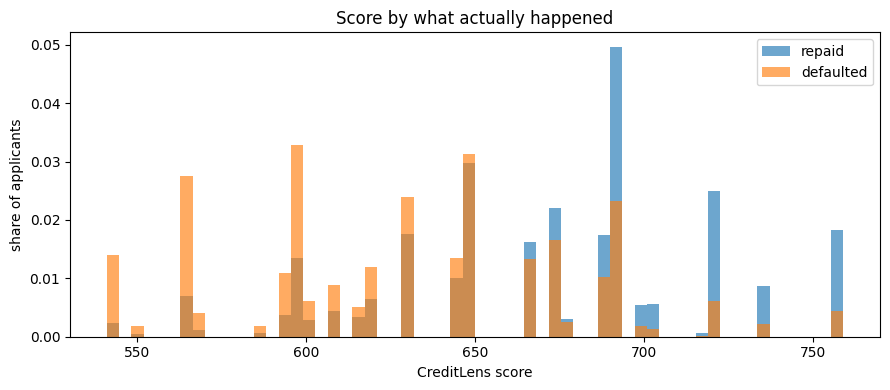

In [75]:
plt.figure(figsize=(9, 4))
plt.hist(scores[y_test.values == 0], bins=60, alpha=0.65, density=True, label="repaid")
plt.hist(scores[y_test.values == 1], bins=60, alpha=0.65, density=True, label="defaulted")
plt.xlabel("CreditLens score")
plt.ylabel("share of applicants")
plt.title("Score by what actually happened")
plt.legend()
plt.tight_layout()
plt.savefig(f"{ART}/score_distribution.png", dpi=120)
plt.show()

## 13. Choosing a cutoff

In [76]:
TARGET_APPROVAL_RATE = 0.80

result = pd.DataFrame({"score": scores, "actual": y_test.values})
cutoff = int(np.percentile(result["score"], (1 - TARGET_APPROVAL_RATE) * 100))
approved = result["score"] >= cutoff

approval_rate = float(approved.mean())
bad_approved = float(result.loc[approved, "actual"].mean())
bad_declined = float(result.loc[~approved, "actual"].mean())

print("cutoff:", cutoff)
print("approved:", f"{approval_rate:.1%}", " bad rate:", f"{bad_approved:.2%}")
print("declined:", f"{1 - approval_rate:.1%}", " bad rate:", f"{bad_declined:.2%}")

bands = pd.cut(result["score"], bins=[300, 500, 550, 600, 650, 700, 850],
               include_lowest=True)
band_table = result.groupby(bands, observed=True).agg(
    applications=("actual", "size"),
    default_rate=("actual", lambda s: round(s.mean() * 100, 2)),
)
band_table.index = band_table.index.astype(str)
band_table.to_csv(f"{ART}/score_bands.csv")
print("\n", band_table.to_string())

cutoff: 629
approved: 81.0%  bad rate: 5.45%
declined: 19.0%  bad rate: 19.27%

                 applications  default_rate
score                                     
(500.0, 550.0]           870         32.76
(550.0, 600.0]          6721         20.68
(600.0, 650.0]         17091         10.63
(650.0, 700.0]         24595          4.96
(700.0, 850.0]         12226          2.07


## 14. Explaining a decline

In [ ]:
import shap

REASONS = {
    "debt_to_income": "Total debt is high compared to income",
    "credit_to_income": "Requested loan is large compared to income",
    "annuity_to_income": "Monthly repayment is high compared to income",
    "credit_utilization": "Existing credit lines are heavily used",
    "bureau_max_overdue_days": "Recent overdue payments on record",
    "bureau_active_loans": "Several loans are currently active",
    "bureau_total_debt": "High total debt across all lenders",
    "bureau_loan_count": "Large number of credit records",
    "inst_late_count": "History of late instalment payments",
    "inst_avg_days_late": "Instalments are usually paid late",
    "inst_avg_pay_ratio": "Instalments are often underpaid",
    "employed_years": "Short employment history",
    "age_years": "Limited credit history length",
}

NOT_A_REASON = {"EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"}

explainer = shap.TreeExplainer(model)
X_sample = X_test.sample(2000, random_state=RANDOM_STATE)

sv = explainer.shap_values(X_sample)
if isinstance(sv, list):
    sv = sv[1]
sv = np.array(sv)
if sv.ndim == 3:
    sv = sv[:, :, 1]

print("shap values:", sv.shape)

shap values: (2000, 138)


/Users/hakas/.pyenv/versions/3.11.9/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [78]:
def wording(name):
    return REASONS.get(name, name.replace("_", " ").capitalize())

def decline_reasons(shap_row, values, names, top_n=4):
    out = []
    for j in np.argsort(shap_row)[::-1]:
        if shap_row[j] <= 0 or len(out) == top_n:
            break
        if names[j] in NOT_A_REASON:
            continue
        out.append((wording(names[j]), values.iloc[j], float(shap_row[j])))
    return out

sample_scores = probability_to_score(
    calibrator.predict(model.predict_proba(X_sample)[:, 1]))
i = int(np.where(sample_scores < cutoff)[0][0])

print("Applicant:", X_sample.index[i])
print("Score:", sample_scores[i], " Cutoff:", cutoff, " Decision: DECLINED")
print("\nReasons:")
for text, value, weight in decline_reasons(sv[i], X_sample.iloc[i], X_sample.columns.tolist()):
    print(f"  {text}")
    print(f"     value {value}, weight {weight:.3f}")

Applicant: 26837
Score: 592  Cutoff: 629  Decision: DECLINED

Reasons:
  Days employed
     value -354.0, weight 0.017
  Instalments are often underpaid
     value 0.8927749005117983, weight 0.015
  Days birth
     value -16250, weight 0.007
  Short employment history
     value 0.9691991786447639, weight 0.006


## 15. Which features mattered overall

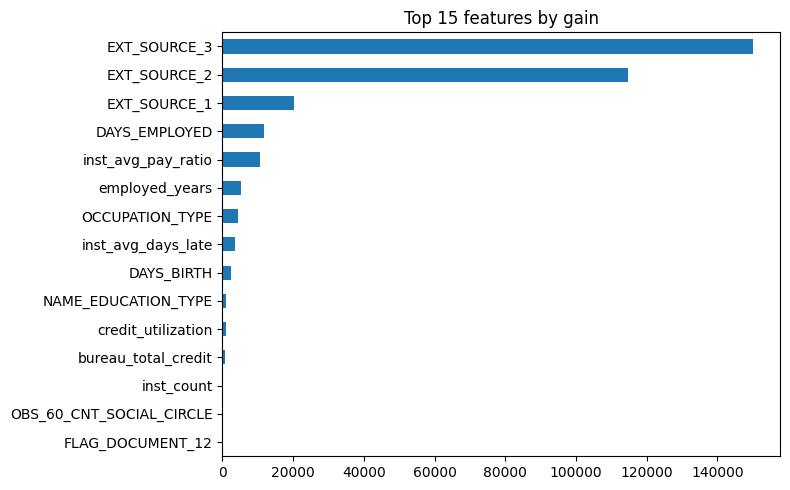

In [79]:
importance = pd.Series(
    model.booster_.feature_importance(importance_type="gain"), index=X.columns)
top = importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
top[::-1].plot(kind="barh")
plt.title("Top 15 features by gain")
plt.tight_layout()
plt.savefig(f"{ART}/feature_importance.png", dpi=120)
plt.show()

## 16. Save everything the app needs

In [80]:
import joblib

joblib.dump(model, f"{ART}/creditlens_lgbm.joblib")
joblib.dump(calibrator, f"{ART}/creditlens_calibrator.joblib")

demo = X_test.sample(500, random_state=RANDOM_STATE)
demo.to_parquet(f"{ART}/sample_applicants.parquet")
y_test.loc[demo.index].to_frame("TARGET").to_parquet(f"{ART}/sample_actuals.parquet")

settings = {
    "base_score": BASE_SCORE,
    "base_odds": float(BASE_ODDS),
    "pdo": PDO,
    "score_floor": FLOOR,
    "score_cap": CAP,
    "cutoff": int(cutoff),
    "target_approval_rate": TARGET_APPROVAL_RATE,
    "scale_pos_weight": float(spw),
    "calibration": "isotonic, fitted on the valid split",
    "test_auc": float(auc_lgb),
    "test_gini": float(2 * auc_lgb - 1),
    "valid_auc": float(auc_valid),
    "baseline_auc": float(auc_baseline),
    "best_iteration": int(model.best_iteration_),
    "n_features": int(X.shape[1]),
    "removed_protected": present,
    "adverse_action": REASONS,
    "non_actionable_features": sorted(NOT_A_REASON),
    "feature_names": X.columns.tolist(),
    "column_order": X.columns.tolist(),
    "categorical_levels": {c: [str(v) for v in X_train[c].cat.categories]
                           for c in cat_cols},
}
with open(f"{ART}/creditlens_scorecard.json", "w") as f:
    json.dump(settings, f, indent=2)

print("saved:", sorted(os.listdir(ART)))

saved: ['creditlens_calibrator.joblib', 'creditlens_lgbm.joblib', 'creditlens_scorecard.json', 'feature_importance.png', 'sample_actuals.parquet', 'sample_applicants.parquet', 'score_bands.csv', 'score_distribution.png']


## 17. A servable model: features in, decision out

In [ ]:
import mlflow

def as_payload(frame):
    out = frame.copy()
    for col in out.select_dtypes(include="category").columns:
        out[col] = out[col].astype("object")
    return out


class CreditLensScorer(mlflow.pyfunc.PythonModel):
    """Wraps model, calibrator and scorecard so one call goes features to decision.

    Serving the raw LightGBM model would return an uncalibrated probability, which
    is not what the notebook reports. Everything the score depends on is bundled
    here so the served answer and the notebook answer cannot drift apart.
    """

    def load_context(self, context):
        import joblib
        self.model = joblib.load(context.artifacts["model"])
        self.calibrator = joblib.load(context.artifacts["calibrator"])
        with open(context.artifacts["settings"]) as f:
            self.settings = json.load(f)

    def predict(self, context, model_input):
        s = self.settings
        frame = model_input.copy()

        # rebuild the exact dtypes used in training, or the codes shift silently
        for col, cats in s["categorical_levels"].items():
            if col in frame.columns:
                frame[col] = pd.Categorical(frame[col].astype("object"), categories=cats)
        frame = frame[s["column_order"]]

        p = self.calibrator.predict(self.model.predict_proba(frame)[:, 1])
        p = np.clip(p, 1e-6, 1 - 1e-6)
        factor = s["pdo"] / np.log(2)
        offset = s["base_score"] - factor * np.log(s["base_odds"])
        score = np.clip(offset + factor * np.log((1 - p) / p),
                        s["score_floor"], s["score_cap"]).round().astype(int)

        return pd.DataFrame({
            "probability_of_default": p.round(4),
            "score": score,
            "decision": np.where(score >= s["cutoff"], "approve", "decline"),
        })

/Users/hakas/.pyenv/versions/3.11.9/lib/python3.11/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


## 18. Log the run to MLflow

In [82]:
RUN_NAME = "lgbm_no_protected"   # change this each time you try something new

example = as_payload(X_test.head(2))

mlflow.set_experiment("creditlens")

with mlflow.start_run(run_name=RUN_NAME) as run:
    mlflow.log_params({
        "n_estimators": 2000,
        "learning_rate": 0.03,
        "num_leaves": 31,
        "scale_pos_weight": round(spw, 3),
        "best_iteration": model.best_iteration_,
        "n_features": X.shape[1],
        "removed_protected": ", ".join(present) if present else "none",
        "calibration": "isotonic",
    })
    mlflow.log_metrics({
        "valid_auc": auc_valid,          # compare runs on this one
        "test_auc": auc_lgb,             # report this one, once
        "gini": 2 * auc_lgb - 1,
        "baseline_auc": auc_baseline,
        "cutoff": cutoff,
        "approval_rate": approval_rate,
        "bad_rate_approved": bad_approved,
        "bad_rate_declined": bad_declined,
    })

    mlflow.log_artifact(f"{ART}/score_distribution.png")
    mlflow.log_artifact(f"{ART}/score_bands.csv")
    mlflow.log_artifact(f"{ART}/feature_importance.png")
    mlflow.log_artifact(f"{ART}/creditlens_scorecard.json")

    mlflow.pyfunc.log_model(
        artifact_path="creditlens_scorer",
        python_model=CreditLensScorer(),
        artifacts={
            "model": f"{ART}/creditlens_lgbm.joblib",
            "calibrator": f"{ART}/creditlens_calibrator.joblib",
            "settings": f"{ART}/creditlens_scorecard.json",
        },
        input_example=example,
        registered_model_name="creditlens",
    )

    print("run id:", run.info.run_id)

print("logged:", RUN_NAME)

2026/08/17 14:38:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/17 14:38:31 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/08/17 14:38:31 INFO mlflow.pyfunc: Inferring model signature from input example
/Users/hakas/.pyenv/versions/3.11.9/lib/python3.11/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realis

run id: a8a98b1602eb4285a4d37f3f05c3c0b4
logged: lgbm_no_protected


Registered model 'creditlens' already exists. Creating a new version of this model...
Created version '2' of model 'creditlens'.


## 19. Check the served model agrees with this notebook

In [83]:
# Load it back the same way a server would, and confirm the numbers match.
served = mlflow.pyfunc.load_model(f"runs:/{run.info.run_id}/creditlens_scorer")

check = X_test.head(5)

# the served model gets the JSON-shaped frame, the notebook keeps its own dtypes
served_out = served.predict(as_payload(check))
notebook_out = probability_to_score(calibrator.predict(model.predict_proba(check)[:, 1]))

print(served_out.to_string(index=False))
print("\nnotebook scores:", list(notebook_out))
print("match:", list(served_out["score"]) == list(notebook_out))

 probability_of_default  score decision
                 0.0611    667  approve
                 0.0909    643  approve
                 0.0503    679  approve
                 0.0131    759  approve
                 0.0198    735  approve

notebook scores: [np.int64(667), np.int64(643), np.int64(679), np.int64(759), np.int64(735)]
match: True


## 20. Serving it as a local API

In [ ]:
as_payload(X_test.head(1)).to_json("request.json", orient="split", index=False)
print("wrote request.json")
print("this is the same shape a SageMaker endpoint will receive later")

wrote request.json
this is the same shape a SageMaker endpoint will receive later
